<a href="https://www.kaggle.com/code/sonawanelalitsunil/rest-for-peak-performance-xgb-lr?scriptVersionId=223149029" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sleep-cycle-and-productivity/sleep_cycle_productivity.csv



<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Rest for Peak Performance  🚀

**Sleep Cycles & Productivity: Understanding the Connection**

**In today's fast-paced world, productivity is often the top priority, but many overlook the critical role sleep plays in performance. Our bodies follow natural sleep cycles that significantly impact cognitive function, mood, and energy levels. Understanding how these cycles work can help us optimize our daily routines for maximum efficiency.**

**A typical sleep cycle lasts about 90 minutes and consists of various stages, including light sleep, deep sleep, and REM (Rapid Eye Movement) sleep. Each stage has its unique benefits for physical and mental recovery. For example, deep sleep is crucial for memory consolidation, while REM sleep supports creativity and problem-solving abilities.**

**When we disrupt these sleep cycles, such as by getting insufficient rest or having poor sleep quality, it can lead to cognitive impairment, reduced concentration, and heightened stress levels. On the other hand, getting restorative sleep in alignment with your natural sleep cycles can boost productivity, enhance decision-making skills, and improve overall well-being.**

**To harness the power of sleep for better productivity, it’s essential to prioritize good sleep hygiene. This includes maintaining a consistent sleep schedule, reducing screen time before bed, and creating a calm sleep environment.**

**By aligning work habits with our natural biological rhythms, we can not only improve productivity but also safeguard our long-term health and mental clarity.**


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Import libraries  🚀

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀Dataset  🚀

In [3]:
df = pd.read_csv("/kaggle/input/sleep-cycle-and-productivity/sleep_cycle_productivity.csv")

In [4]:
df.head()

,Date,Person_ID,Age,Gender,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,2024-04-12,1860,32,Other,23.33,4.61,5.28,3,86,87,116,8.808920,8,3,6
1,2024-11-04,1769,41,Female,21.02,2.43,5.41,5,32,21,88,6.329833,10,3,7
2,2024-08-31,2528,20,Male,22.10,3.45,5.35,7,17,88,59,8.506306,10,9,10
3,2024-02-22,8041,37,Other,23.10,6.65,7.55,8,46,34,80,6.070240,8,4,2
4,2024-02-23,4843,46,Other,21.42,4.17,6.75,10,61,269,94,11.374994,8,7,9


In [5]:
df.tail()

,Date,Person_ID,Age,Gender,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
4995,2024-01-03,5192,38,Female,22.78,4.15,5.37,1,55,216,96,9.384504,5,2,1
4996,2024-06-02,7134,55,Male,21.48,5.39,7.91,4,70,81,177,5.016193,5,6,2
4997,2024-08-13,6265,44,Female,22.02,2.82,4.80,6,21,90,139,11.788651,2,7,1
4998,2024-12-26,4205,55,Other,23.47,7.87,8.40,9,15,87,161,7.093145,8,1,6
4999,2024-04-11,2304,58,Male,20.72,1.37,4.65,1,6,26,35,5.615948,6,9,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           5000 non-null   object 
 1   Person_ID                      5000 non-null   int64  
 2   Age                            5000 non-null   int64  
 3   Gender                         5000 non-null   object 
 4   Sleep Start Time               5000 non-null   float64
 5   Sleep End Time                 5000 non-null   float64
 6   Total Sleep Hours              5000 non-null   float64
 7   Sleep Quality                  5000 non-null   int64  
 8   Exercise (mins/day)            5000 non-null   int64  
 9   Caffeine Intake (mg)           5000 non-null   int64  
 10  Screen Time Before Bed (mins)  5000 non-null   int64  
 11  Work Hours (hrs/day)           5000 non-null   float64
 12  Productivity Score             5000 non-null   i

In [7]:
df.dtypes

Date                              object
Person_ID                          int64
Age                                int64
Gender                            object
Sleep Start Time                 float64
Sleep End Time                   float64
Total Sleep Hours                float64
Sleep Quality                      int64
Exercise (mins/day)                int64
Caffeine Intake (mg)               int64
Screen Time Before Bed (mins)      int64
Work Hours (hrs/day)             float64
Productivity Score                 int64
Mood Score                         int64
Stress Level                       int64
dtype: object

In [8]:
df.describe()

,Person_ID,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5527.152200,38.590600,22.005350,4.980262,6.974902,5.520800,43.962600,146.71140,91.421200,7.987873,5.644200,5.370600,5.548000
std,2595.391771,12.302799,1.157591,1.862508,1.454033,2.863845,25.798541,85.83139,52.079123,2.275734,2.872221,2.835783,2.888419
min,1000.000000,18.000000,20.000000,0.560000,4.500000,1.000000,0.000000,0.00000,0.000000,4.000067,1.000000,1.000000,1.000000
25%,3258.000000,28.000000,21.020000,3.660000,5.690000,3.000000,22.000000,73.00000,46.000000,6.032720,3.000000,3.000000,3.000000
50%,5603.000000,39.000000,22.020000,4.970000,6.960000,5.000000,44.000000,144.00000,92.000000,7.998295,6.000000,5.000000,6.000000
75%,7749.500000,49.000000,23.000000,6.310000,8.210000,8.000000,66.000000,220.00000,136.000000,9.905024,8.000000,8.000000,8.000000
max,9998.000000,59.000000,23.980000,9.420000,9.500000,10.000000,89.000000,299.00000,179.000000,11.999141,10.000000,10.000000,10.000000


In [9]:
df.isnull().sum()

Date                             0
Person_ID                        0
Age                              0
Gender                           0
Sleep Start Time                 0
Sleep End Time                   0
Total Sleep Hours                0
Sleep Quality                    0
Exercise (mins/day)              0
Caffeine Intake (mg)             0
Screen Time Before Bed (mins)    0
Work Hours (hrs/day)             0
Productivity Score               0
Mood Score                       0
Stress Level                     0
dtype: int64

In [10]:
df.count

<bound method DataFrame.count of             Date  Person_ID  Age  Gender  Sleep Start Time  Sleep End Time  \
0     2024-04-12       1860   32   Other             23.33            4.61   
1     2024-11-04       1769   41  Female             21.02            2.43   
2     2024-08-31       2528   20    Male             22.10            3.45   
3     2024-02-22       8041   37   Other             23.10            6.65   
4     2024-02-23       4843   46   Other             21.42            4.17   
...          ...        ...  ...     ...               ...             ...   
4995  2024-01-03       5192   38  Female             22.78            4.15   
4996  2024-06-02       7134   55    Male             21.48            5.39   
4997  2024-08-13       6265   44  Female             22.02            2.82   
4998  2024-12-26       4205   55   Other             23.47            7.87   
4999  2024-04-11       2304   58    Male             20.72            1.37   

      Total Sleep Hours  Sleep

In [11]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [12]:
df.columns

Index(['Date', 'Person_ID', 'Age', 'Gender', 'Sleep Start Time',
       'Sleep End Time', 'Total Sleep Hours', 'Sleep Quality',
       'Exercise (mins/day)', 'Caffeine Intake (mg)',
       'Screen Time Before Bed (mins)', 'Work Hours (hrs/day)',
       'Productivity Score', 'Mood Score', 'Stress Level'],
      dtype='object')


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 EDA 🚀

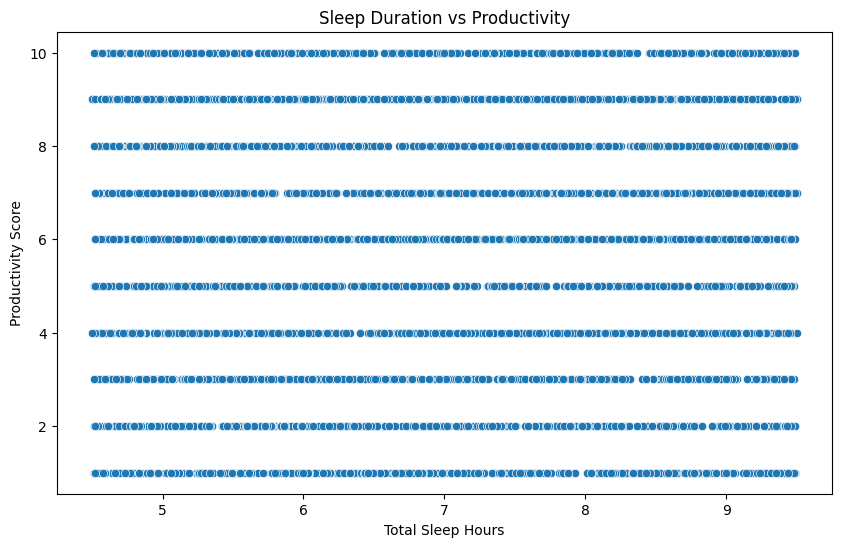

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total Sleep Hours', y='Productivity Score')
plt.title('Sleep Duration vs Productivity')
plt.xlabel('Total Sleep Hours')
plt.ylabel('Productivity Score')
plt.show()

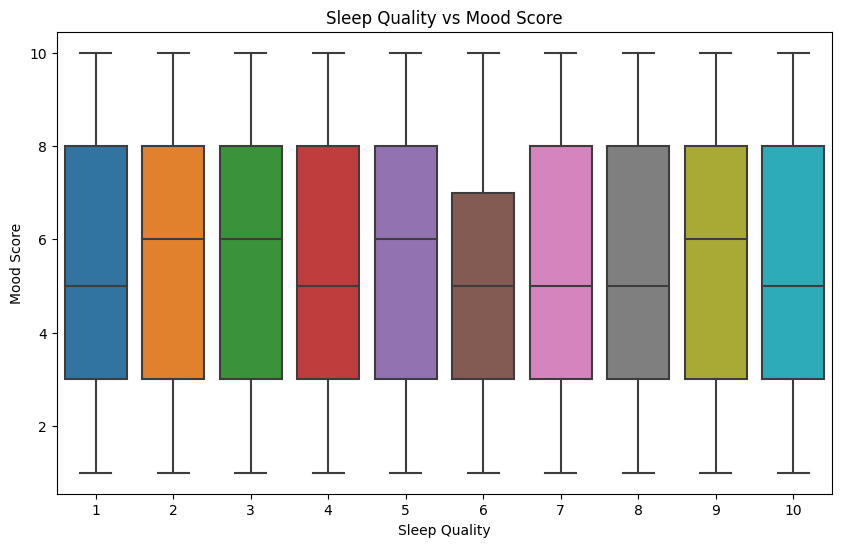

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Sleep Quality', y='Mood Score')
plt.title('Sleep Quality vs Mood Score')
plt.xlabel('Sleep Quality')
plt.ylabel('Mood Score')
plt.show()

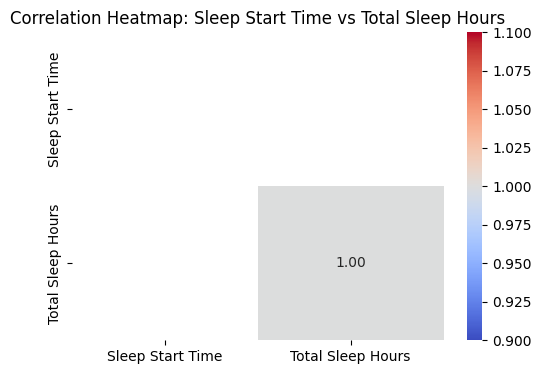

In [15]:
df['Sleep Start Time'] = pd.to_datetime(df['Sleep Start Time']).dt.hour
correlation = df[['Sleep Start Time', 'Total Sleep Hours']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Sleep Start Time vs Total Sleep Hours')
plt.show()

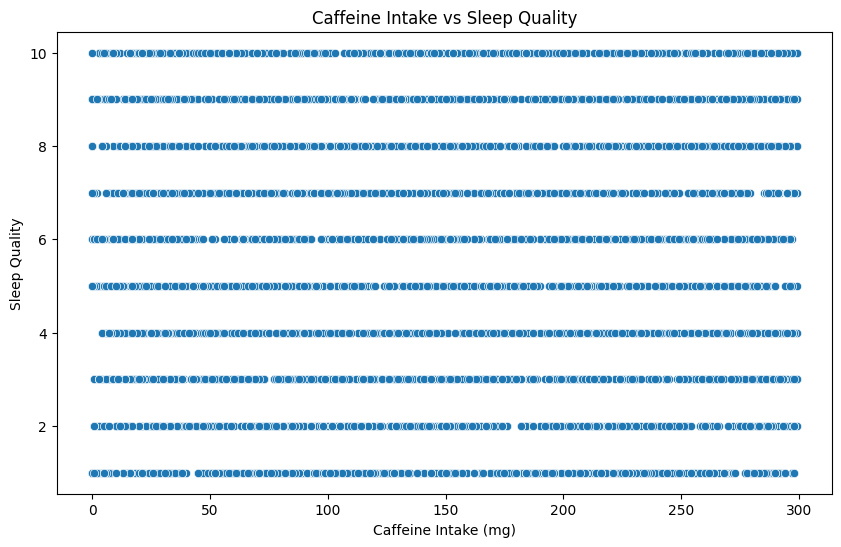

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Caffeine Intake (mg)', y='Sleep Quality')
plt.title('Caffeine Intake vs Sleep Quality')
plt.xlabel('Caffeine Intake (mg)')
plt.ylabel('Sleep Quality')
plt.show()

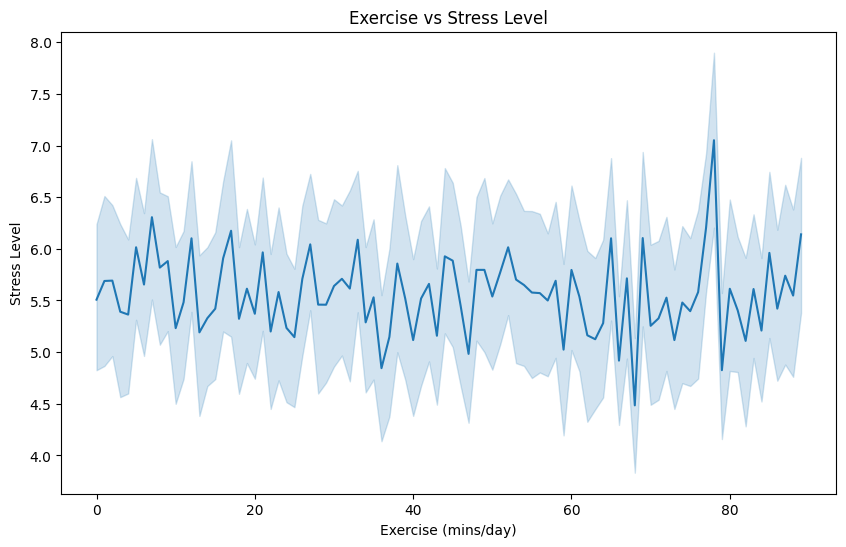

In [17]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Exercise (mins/day)', y='Stress Level')
plt.title('Exercise vs Stress Level')
plt.xlabel('Exercise (mins/day)')
plt.ylabel('Stress Level')
plt.show()

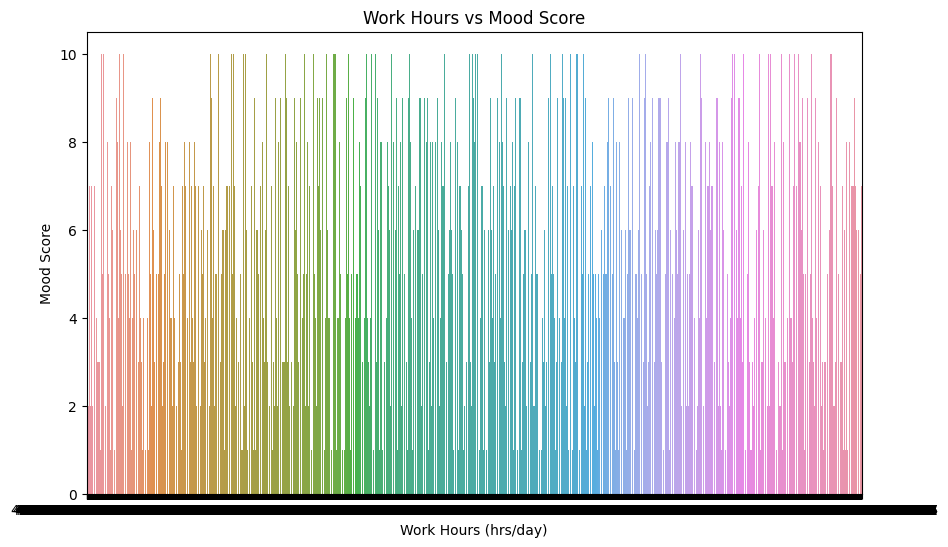

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Work Hours (hrs/day)', y='Mood Score')
plt.title('Work Hours vs Mood Score')
plt.xlabel('Work Hours (hrs/day)')
plt.ylabel('Mood Score')
plt.show()

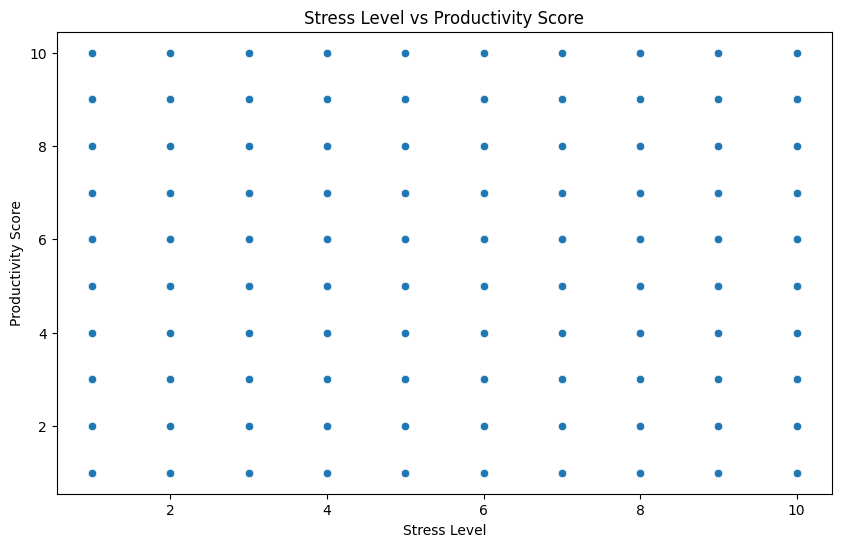

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Stress Level', y='Productivity Score')
plt.title('Stress Level vs Productivity Score')
plt.xlabel('Stress Level')
plt.ylabel('Productivity Score')
plt.show()

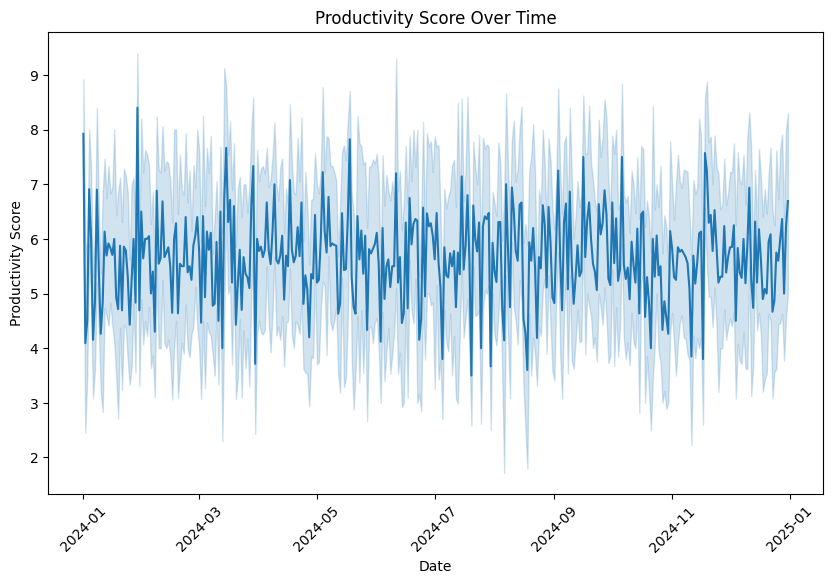

In [20]:
df['Date'] = pd.to_datetime(df['Date'])
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Date', y='Productivity Score')
plt.title('Productivity Score Over Time')
plt.xlabel('Date')
plt.ylabel('Productivity Score')
plt.xticks(rotation=45)
plt.show()

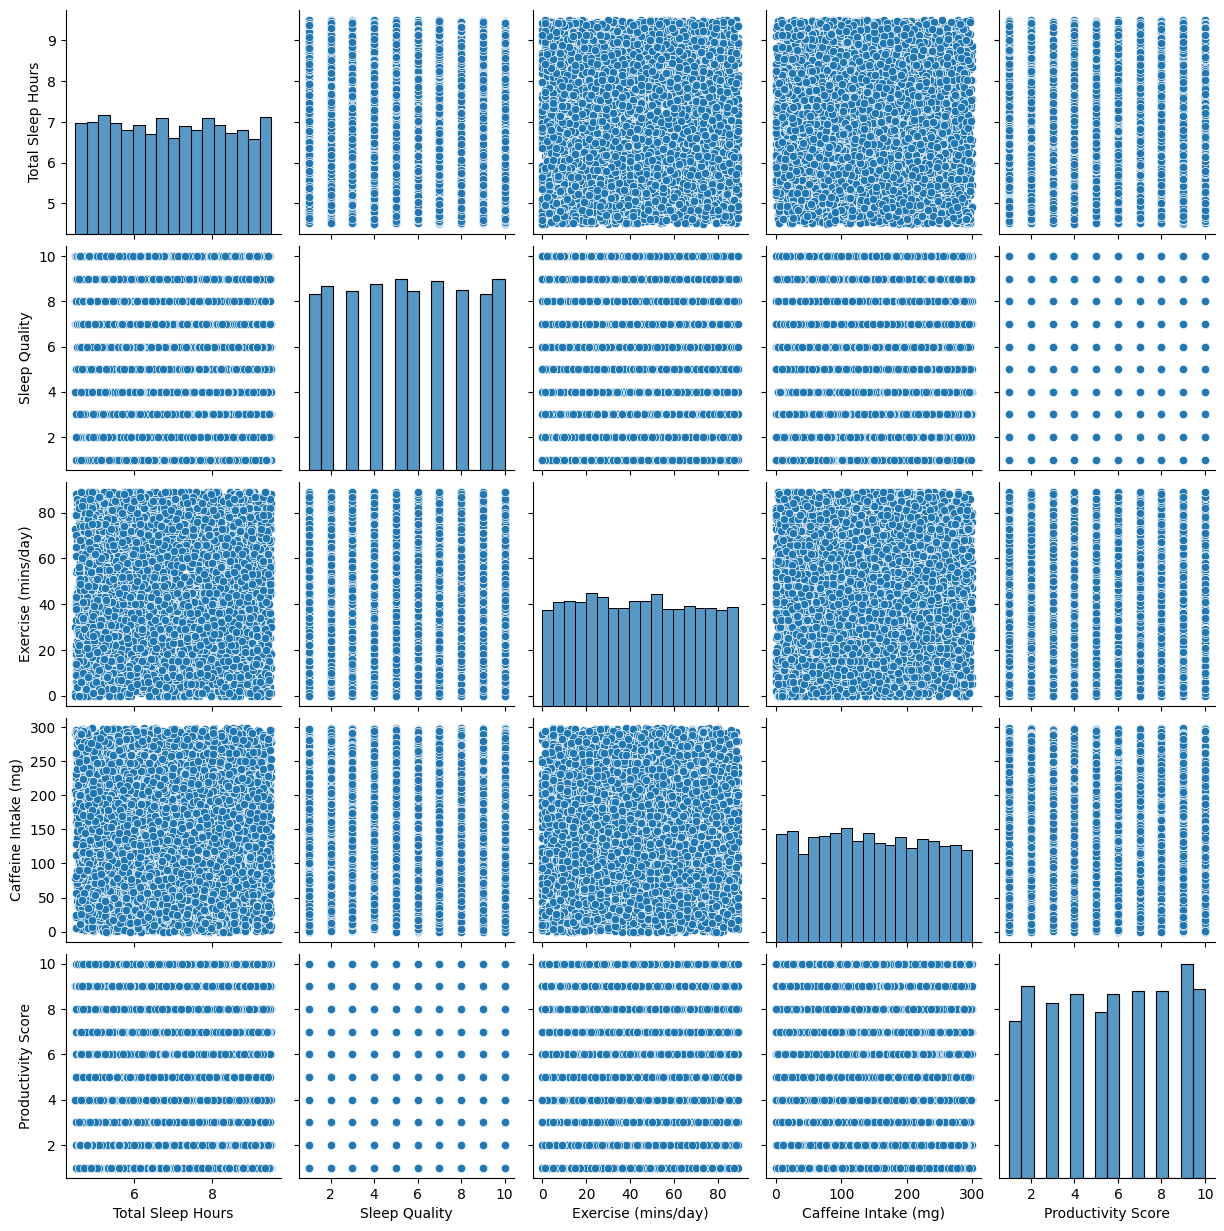

In [21]:
sns.pairplot(df[['Total Sleep Hours', 'Sleep Quality', 'Exercise (mins/day)', 'Caffeine Intake (mg)', 'Productivity Score']])
plt.show()


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Predictions  🚀

In [22]:
print(df.columns)

Index(['Date', 'Person_ID', 'Age', 'Gender', 'Sleep Start Time',
       'Sleep End Time', 'Total Sleep Hours', 'Sleep Quality',
       'Exercise (mins/day)', 'Caffeine Intake (mg)',
       'Screen Time Before Bed (mins)', 'Work Hours (hrs/day)',
       'Productivity Score', 'Mood Score', 'Stress Level'],
      dtype='object')


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance

# Assuming your dataframe 'df' is already loaded with the necessary columns.

# Create a binary target 'High_Productivity' based on median split
median_productivity = df['Productivity Score'].median()
df['High_Productivity'] = (df['Productivity Score'] >= median_productivity).astype(int)

# Select features and target for modeling
# We drop columns that are identifiers or less relevant, like Date and Person_ID
feature_cols = ['Age', 'Sleep Start Time', 'Sleep End Time', 'Total Sleep Hours',
                'Sleep Quality', 'Exercise (mins/day)', 'Caffeine Intake (mg)',
                'Screen Time Before Bed (mins)', 'Work Hours (hrs/day)', 'Mood Score', 'Stress Level']

# Check if feature columns exist after renaming
print('Model features:', feature_cols)

X = df[feature_cols].copy()
y = df['High_Productivity']

# Handle missing values if any (for simplicity, we fill with the median)
X = X.fillna(X.median())

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy score and display it
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score:', accuracy)

Model features: ['Age', 'Sleep Start Time', 'Sleep End Time', 'Total Sleep Hours', 'Sleep Quality', 'Exercise (mins/day)', 'Caffeine Intake (mg)', 'Screen Time Before Bed (mins)', 'Work Hours (hrs/day)', 'Mood Score', 'Stress Level']
Accuracy Score: 0.497


In [24]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize classifiers
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Classifier': SVC()
}

# Store accuracy scores
accuracy_scores = {}

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[model_name] = accuracy


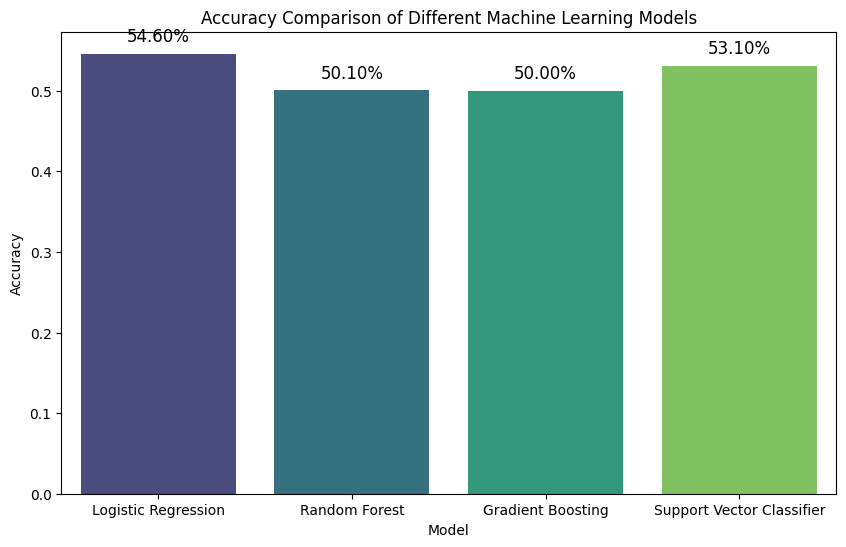

In [25]:
# Plotting the accuracy scores of each model with percentages
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')

# Adding accuracy percentage labels on top of each bar
for i, score in enumerate(accuracy_scores.values()):
    plt.text(i, score + 0.01, f'{score * 100:.2f}%', ha='center', va='bottom', fontsize=12)

# Adding title and labels
plt.title('Accuracy Comparison of Different Machine Learning Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()

# thank you !!! pls Upvotes...